# Temas Tratados en el Trabajo Práctico 8

* Aprendizaje estadístico.

* Evolución de la verosimilitud de una hipótesis en función de observaciones.

* Aprendizaje no supervisado. Algoritmo K-means.

* Aprendizaje supervisado. Algoritmo Knn.

* Aprendizaje por refuerzo. Algoritmo Q-Learning.

## Ejercicios Teóricos

1. Un fabricante de tornillos vende cajas que contienen 1000 tornillos de cabeza redonda con tres tipos de recubrimiento electrolítico (cincado, cobre y níquel). Cada caja se rellena
con diferentes proporciones que pueden variar de la siguiente manera:

&emsp;&emsp;a: Todos los tornillos están recubiertos de níquel. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;b: El 70% de los tornillos están recubiertos de níquel, el 20% de cobre, el resto está cincado. 15 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;c: El 50% de los tornillos están recubiertos de níquel, el 25% de cobre y el resto está cincado. 50 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;d: El 20 % de los tornillos están recubiertos de níquel, el 50% de cobre y el resto está cincado. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;e: Todos los tornillos están recubiertos de cobre. 10 de cada 100 cajas se llenan de esta manera.

&emsp;&emsp;1.1 ¿Cuál es la distribución a priori sobre las hipótesis?

&emsp;Considerando que los 10 primeros tornillos que se extraen de una caja de muestra son de cobre:

&emsp;&emsp;1.2 Calcule la probabilidad de cada hipótesis dado que los 10 primeros tornillos fueron de cobre.


&emsp;&emsp;1.3 Grafique la evolución de la verosimilitud de cada hipótesis en función del número de tornillos extraídos de la caja.

&emsp;&emsp;1.4 Para cada hipótesis, ¿cuál es la probabilidad de que el cuarto tornillo extraído sea de cobre?

2. ¿Qué diferencia principal existe entre un algoritmo supervisado y un algoritmo no supervisado?

#### Aprendizaje Supervisado
-El algoritmo aprende a partir de un conjunto de datos que incluye tanto las variables de entrada (features, $X$) como la variable objetivo o etiqueta de salida deseada.

-Objetivo: Encontrar una función matemática o regla que relacione las entradas con las salidas para predecir la etiqueta de datos nuevos e invisibles.
#### Aprendizaje  No Supervisado
-El algoritmo recibe únicamente datos de entrada  sin ninguna etiqueta ni resultado previo. El sistema debe descubrir patrones intrínsecos, agrupaciones naturales o estructuras ocultas por sí mismo.

-Objetivo: Descubrir la estructura subyacente, regularidades o distribuciones dentro del espacio de datos.


## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

3. Genere un conjunto de 23 puntos que contengan coordenadas *xy* aleatorias con valores contenidos en el intervalo [0, 5] y grafique los puntos obtenidos en un gráfico.

&emsp;&emsp;3.1 Implemente un algoritmo K-means que clasifique 20 de los puntos en 2 grupos y grafique el resultado asignando un color a cada uno.

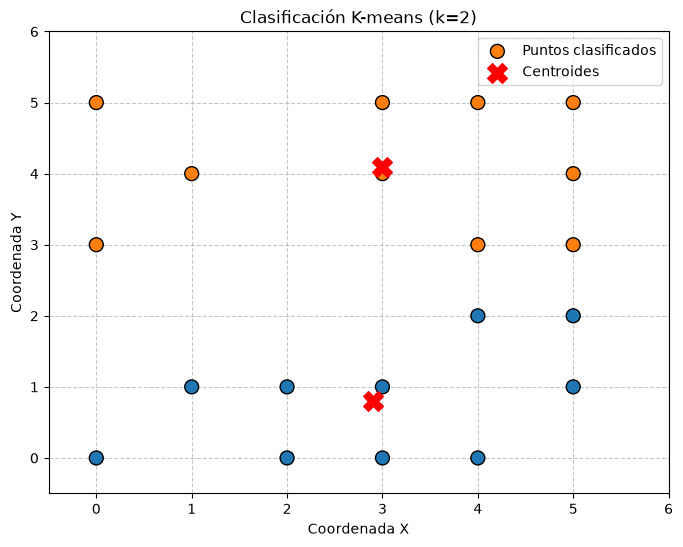

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Definir los puntos (pares de números del 0 al 5)
puntos_totales = np.array([
    [5, 4], [4, 3], [2, 1], [3, 1], [0, 0], 
    [5, 3], [5, 2], [3, 0], [1, 1], [4, 5], 
    [4, 0], [1, 4], [0, 5], [5, 1], [5, 5], 
    [3, 4], [2, 0], [0, 3], [3, 5], [4, 2], 
    [2, 2], [3, 3], [4, 4]
])

# 2. Tomar solo 20 puntos como pide el inciso 3.1
# (Si necesitas usar los 23, simplemente cambia a: puntos = puntos_totales)
puntos = puntos_totales[:20]

# 3. Implementar el algoritmo K-means para 2 grupos
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(puntos)

# 4. Obtener las clasificaciones (etiquetas) y los centroides
etiquetas = kmeans.labels_
centroides = kmeans.cluster_centers_

# 5. Graficar los resultados
plt.figure(figsize=(8, 6))

# Asignar colores según el grupo (0 o 1)
colores = ['#1f77b4' if etiqueta == 0 else '#ff7f0e' for etiqueta in etiquetas]

# Graficar los puntos
plt.scatter(puntos[:, 0], puntos[:, 1], c=colores, s=100, edgecolors='black', zorder=2, label='Puntos clasificados')

# Graficar los centroides
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', s=200, marker='X', zorder=3, label='Centroides')

# Configurar el gráfico para que coincida con el rango [0, 5]
plt.xlim(-0.5, 6)
plt.ylim(-0.5, 6)
plt.xticks(np.arange(0, 7, 1))
plt.yticks(np.arange(0, 7, 1))

plt.title('Clasificación K-means (k=2)')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True, linestyle='--', alpha=0.7, zorder=1)
plt.legend()
plt.show()


&emsp;&emsp;3.2 Tome los tres puntos restantes y clasifíquelos en los grupos obtenidos anteriormente usando el algoritmo Knn. Utilice distintos valores de K y anote lo que observa con esta elección.

4. La imagen mostrada abajo muestra una red de salas y cómo se comunican entre ellas. Implemente un algoritmo Q-Learning con un factor despreciativo $γ = 0.9$. La matriz de recompensas debe asignar un valor de 0 a cada camino accesible y un valor de 100 a caminos que lleven a la sala del tesoro.

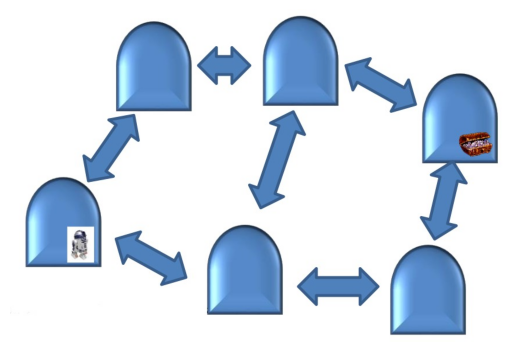

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1dkDruEIPa7f-BAmjI47TZl3bxaqYf6a9"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

&emsp;&emsp;4.1 Dibuje un diagrama con la asignación de recompensas correspondiente a cada estado.

&emsp;&emsp;4.2 Diseñe y muestre la matriz de recompensas.

&emsp;&emsp;4.3 Obtenga la matriz Q óptima, normalícela respecto al valor máximo encontrado y grafique la política obtenida en el diagrama mostrado inicialmente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2017) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)